In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gold_data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.shape

(6468, 24)

In [2]:
# تحويل سعر الأونصة إلى سعر الجرام (عيار 24)
df["24K"] = df["Gold_Close"] / 31.1035

# حساب بقية العيارات
df["22K"] = df["24K"] * (22/24)
df["21K"] = df["24K"] * (21/24)
df["18K"] = df["24K"] * (18/24)

In [3]:
df = df.dropna(subset=["Gold_Close"]).copy()

# day-of-week / month seasonality, added straight to df so the latest row already has everything it needs later
dow = df.index.dayofweek
df["dow_sin"] = np.sin(2*np.pi*dow/7)
df["dow_cos"] = np.cos(2*np.pi*dow/7)
month = df.index.month
df["month_sin"] = np.sin(2*np.pi*month/12)
df["month_cos"] = np.cos(2*np.pi*month/12)

print(df.shape)
df[["Gold_Close","24K","22K","21K","18K","RSI","MACD","DXY","VIX"]].tail()

(6468, 32)


,Gold_Close,24K,22K,21K,18K,RSI,MACD,DXY,VIX
Date,,,,,,,,,
2026-07-24,4067.600098,130.776282,119.878259,114.429247,98.082212,45.939508,-51.155755,101.470001,18.580000
2026-07-27,4074.500000,130.998119,120.081609,114.623354,98.248589,46.480858,-46.768670,101.510002,18.670000
2026-07-28,4036.300049,129.769963,118.955800,113.548718,97.327472,43.862116,-45.845807,101.379997,18.209999
2026-07-29,4034.699951,129.718519,118.908642,113.503704,97.288889,43.750924,-44.727951,100.800003,20.660000
2026-07-30,4100.100098,131.821181,120.836082,115.343533,98.865886,49.397363,-38.125311,100.010002,17.090000


### Feature Engineering
we point `FEATURE_COLS` at the columns and add the karat price + the seasonality terms. `Gold_Close` itself is dropped from the feature list since `24K` is just a rescaled copy of it, keeping both would be redundant

The target is the 24K price 21 trading days out (~1 month ahead).
- Important: the dataset's own `Target` column is next-day close, not 1-month-ahead, so it gets dropped rather than used, using it as a feature would leak almost the exact answer

In [4]:
HORIZON = 21  # ~1 trading month ahead (21 trading days)

FEATURE_COLS = [
    "24K", "Gold_Open", "Gold_High", "Gold_Low", "Gold_Volume",
    "DXY", "SP500", "Oil", "VIX",
    "Lag1", "Lag7", "MA7", "MA30", "EMA20", "Daily_Return",
    "RSI", "MACD", "MACD_Signal", "MACD_Hist",
    "BB_Upper", "BB_Middle", "BB_Lower", "ATR",
    "dow_sin", "dow_cos", "month_sin", "month_cos",
]  # note: "Target" (next-day close) is intentionally excluded — it would leak the answer

feat_df = df.copy()
feat_df["target_24K"] = feat_df["24K"].shift(-HORIZON)
feat_df = feat_df.dropna(subset=FEATURE_COLS + ["target_24K"])
print("Usable rows after feature engineering:", feat_df.shape)
feat_df[FEATURE_COLS + ["target_24K"]].tail()

Usable rows after feature engineering: (6447, 33)


,24K,Gold_Open,Gold_High,Gold_Low,Gold_Volume,DXY,SP500,Oil,VIX,Lag1,...,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,dow_sin,dow_cos,month_sin,month_cos,target_24K
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-24,128.291030,4104.399902,4104.700195,3963.300049,353.0,101.610001,7358.220215,70.339996,18.629999,4129.899902,...,-16.455552,4624.737757,4313.730005,4002.722253,100.018148,0.974928,-0.222521,1.224647e-16,-1.0,130.776282
2026-06-25,129.583487,3988.399902,4030.500000,3986.699951,2724.0,101.430000,7357.490234,71.919998,18.889999,3990.300049,...,-18.690787,4620.678566,4292.880005,3965.081444,96.002569,0.433884,-0.900969,1.224647e-16,-1.0,130.998119
2026-06-26,131.133151,4078.699951,4078.699951,4078.699951,1431.0,101.360001,7354.020020,69.230003,18.410000,4030.500000,...,-15.098011,4597.941482,4271.850012,3945.758542,92.588097,-0.433884,-0.900969,1.224647e-16,-1.0,129.769963
2026-06-29,129.319853,4057.500000,4070.000000,4003.199951,785.0,101.110001,7440.430176,70.750000,17.650000,4078.699951,...,-14.681598,4559.948473,4244.940015,3929.931557,91.367518,0.000000,1.000000,1.224647e-16,-1.0,129.718519
2026-06-30,129.339139,4002.600098,4049.699951,3962.500000,1108.0,101.190002,7499.359863,69.500000,16.450001,4022.300049,...,-12.606842,4532.874489,4222.325000,3911.775511,91.069835,0.781831,0.623490,1.224647e-16,-1.0,131.821181


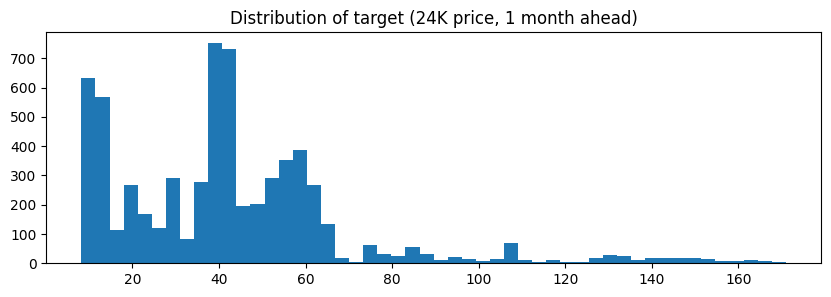

Skew: 1.6380445326263973


In [5]:
# Target distribution check (skew)
plt.figure(figsize=(10,3))
plt.hist(feat_df["target_24K"], bins=50)
plt.title("Distribution of target (24K price, 1 month ahead)")
plt.show()
print("Skew:", feat_df["target_24K"].skew())

### Train / Validation / Test Split
Since this is time-series data we split by date instead of shuffling.
70% train, 15% val, 15% test, in that order. Shuffling would let the model peek at future prices during training, which isn't realistic

In [6]:
X = feat_df[FEATURE_COLS].values
y = feat_df["target_24K"].values
dates = feat_df.index

n = len(feat_df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]
dates_test = dates[val_end:]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (4512, 27)  Val: (967, 27)  Test: (968, 27)


### Scaling
Scaled X and y with StandardScaler, fitting only on the training set so nothing from validation/test leaks into it

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler().fit(X_train)
X_train_s = scaler_X.transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))
y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

### Baselines
Before trusting whatever the ANN outputs, we wanted something to compare it against, a naive random-walk baseline (just "price in a month = price today") and a linear regression on the same features

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Naive baseline: assume no change over the horizon
naive_pred = X_test[:, 0]  # column 0 = current 24K price

# Linear regression baseline
lin_reg = LinearRegression().fit(X_train_s, y_train_s)
lin_pred = scaler_y.inverse_transform(lin_reg.predict(X_test_s).reshape(-1, 1)).ravel()

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"{label:30s} MAE={mae:7.3f}  RMSE={rmse:7.3f}  MAPE={mape:5.2f}%  R2={r2:6.4f}")
    return dict(MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

baseline_results = {}
baseline_results["naive"] = evaluate(y_test, naive_pred, "Naive (no-change) baseline")
baseline_results["linreg"] = evaluate(y_test, lin_pred, "Linear Regression baseline")

Naive (no-change) baseline     MAE=  4.011  RMSE=  5.908  MAPE= 3.99%  R2=0.9663
Linear Regression baseline     MAE=  5.124  RMSE=  7.074  MAPE= 5.14%  R2=0.9516


### ANN Architecture (with Regularization)
Dense layers with L2 and Dropout so it doesn't just memorize the training set. linear output since this is regression

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

def build_model(n_features, units1=128, units2=64, units3=32,
                 dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units1, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout1),
        layers.Dense(units2, activation="relu", kernel_regularizer=regularizers.l2(l2reg)),
        layers.Dropout(dropout2),
        layers.Dense(units3, activation="relu"),
        layers.Dense(1, activation="linear"),   # linear output -> regression
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mae",              # more robust to outliers than MSE
        metrics=["mae", "mse"],
    )
    return model

build_model(X_train_s.shape[1]).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 0 (0.00 B)

### Hyperparameter Tuning (manual search)
Tried a handful of combos of layer sizes, dropout, L2 strength, and learning rate, each trained with early stopping, and kept whichever one had the lowest validation MAE.

In [10]:
configs = [
    dict(units1=64,  units2=32,  units3=16, dropout1=0.2, dropout2=0.1, l2reg=1e-4, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.3, dropout2=0.2, l2reg=1e-3, lr=1e-3),
    dict(units1=128, units2=64,  units3=32, dropout1=0.4, dropout2=0.3, l2reg=1e-3, lr=5e-4),
    dict(units1=256, units2=128, units3=64, dropout1=0.4, dropout2=0.3, l2reg=1e-2, lr=1e-3),
]

tuning_results = []
for i, cfg in enumerate(configs):
    tf.keras.backend.clear_session()
    model = build_model(X_train_s.shape[1], **cfg)
    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    hist = model.fit(X_train_s, y_train_s, validation_data=(X_val_s, y_val_s),
                      epochs=80, batch_size=32, callbacks=[es], verbose=0)
    best_val_mae = min(hist.history["val_mae"])
    tuning_results.append({"config": cfg, "val_mae_scaled": best_val_mae})
    print(f"Config {i}: {cfg} -> val_mae(scaled)={best_val_mae:.4f}")

best_cfg = min(tuning_results, key=lambda r: r["val_mae_scaled"])["config"]
print("\nBest config:", best_cfg)

Config 0: {'units1': 64, 'units2': 32, 'units3': 16, 'dropout1': 0.2, 'dropout2': 0.1, 'l2reg': 0.0001, 'lr': 0.001} -> val_mae(scaled)=0.3477
Config 1: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.3, 'dropout2': 0.2, 'l2reg': 0.001, 'lr': 0.001} -> val_mae(scaled)=0.2593
Config 2: {'units1': 128, 'units2': 64, 'units3': 32, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.001, 'lr': 0.0005} -> val_mae(scaled)=0.2431
Config 3: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001} -> val_mae(scaled)=0.2137

Best config: {'units1': 256, 'units2': 128, 'units3': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'l2reg': 0.01, 'lr': 0.001}


### Training the Final Model
Using the best config from the tuning step, now with the full callback stack,EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [11]:
tf.keras.backend.clear_session()
final_model = build_model(X_train_s.shape[1], **best_cfg)

cb_list = [
    callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
    callbacks.ModelCheckpoint("best_gold_model.keras", monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=8, min_lr=1e-6),
]

history = final_model.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300, batch_size=32,
    callbacks=cb_list, verbose=1,
)

Epoch 1/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5529 - mae: 0.2201 - mse: 0.0917 - val_loss: 0.8938 - val_mae: 0.1757 - val_mse: 0.0494 - learning_rate: 0.0010
Epoch 2/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5990 - mae: 0.1533 - mse: 0.0407 - val_loss: 0.5597 - val_mae: 0.3010 - val_mse: 0.1171 - learning_rate: 0.0010
Epoch 3/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3072 - mae: 0.1344 - mse: 0.0321 - val_loss: 0.4423 - val_mae: 0.3319 - val_mse: 0.1395 - learning_rate: 0.0010
Epoch 4/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2089 - mae: 0.1287 - mse: 0.0285 - val_loss: 0.4013 - val_mae: 0.3435 - val_mse: 0.1493 - learning_rate: 0.0010
Epoch 5/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1694 - mae: 0.1238 - mse: 0.0267 - val_loss: 0.4127 - val_mae: 0.3762 - val_mse: 0.1766 - learning_rate: 0.0010
Epoch 6/300
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1521 - mae: 0.1204 - mse: 0.0258 - val_loss: 0.4885 - val_mae:

### Evaluation
Plotting train vs. val loss to check for over/underfitting, then comparing the test metrics against the baselines.

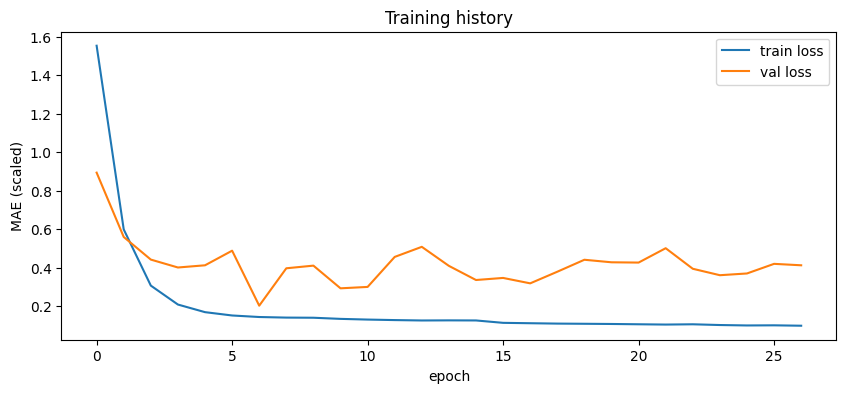

In [12]:
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("MAE (scaled)"); plt.legend()
plt.title("Training history")
plt.show()

Test set comparison ---
Naive baseline                 MAE=  4.011  RMSE=  5.908  MAPE= 3.99%  R2=0.9663
Linear Regression baseline     MAE=  5.124  RMSE=  7.074  MAPE= 5.14%  R2=0.9516
ANN (final model)              MAE= 10.762  RMSE= 13.254  MAPE=10.93%  R2=0.8302


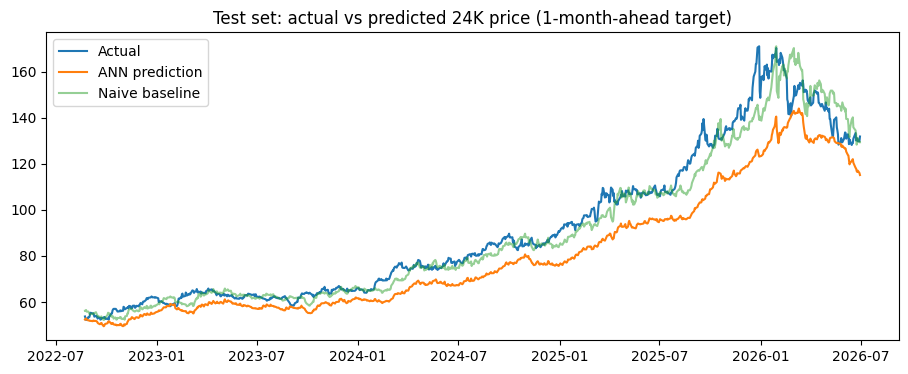

In [13]:
y_test_pred_s = final_model.predict(X_test_s, verbose=0).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

print("Test set comparison ---")
evaluate(y_test, naive_pred, "Naive baseline")
evaluate(y_test, lin_pred, "Linear Regression baseline")
ann_metrics = evaluate(y_test, y_test_pred, "ANN (final model)")

plt.figure(figsize=(11,4))
plt.plot(dates_test, y_test, label="Actual")
plt.plot(dates_test, y_test_pred, label="ANN prediction")
plt.plot(dates_test, naive_pred, label="Naive baseline", alpha=0.5)
plt.legend(); plt.title("Test set: actual vs predicted 24K price (1-month-ahead target)")
plt.show()

### Predicting Next Month + Karat Conversion + Buy/Sell Signal


In [14]:
latest_row = df[FEATURE_COLS].iloc[[-1]].values
latest_row_s = scaler_X.transform(latest_row)

pred_s = final_model.predict(latest_row_s, verbose=0).ravel()[0]
pred_24K = scaler_y.inverse_transform([[pred_s]])[0][0]

current_24K = df["24K"].iloc[-1]
pct_change = (pred_24K - current_24K) / current_24K * 100

karat_forecast = {
    "24K": pred_24K,
    "21K": pred_24K * 21/24,
    "18K": pred_24K * 18/24,
}

BUY_THRESHOLD, SELL_THRESHOLD = 2.0, -2.0   # % move considered "meaningful"
if pct_change > BUY_THRESHOLD:
    signal = "BUY NOW / SELL LATER — price expected to rise"
elif pct_change < SELL_THRESHOLD:
    signal = "WAIT TO BUY / SELL NOW — price expected to fall"
else:
    signal = "HOLD — no strong trend expected"

print(f"Current 24K price/gram: {current_24K:.2f}")
print(f"Predicted price/gram in ~1 month:")
for k, v in karat_forecast.items():
    print(f"  {k}: {v:.2f}")
print(f"\nExpected change: {pct_change:+.2f}%")
print(f"Signal: {signal}")
print("\n(Educational project! not financial advice!)")

Current 24K price/gram: 131.82
Predicted price/gram in ~1 month:
  24K: 114.58
  21K: 100.26
  18K: 85.93

Expected change: -13.08%
Signal: WAIT TO BUY / SELL NOW — price expected to fall

(Educational project — not financial advice.)
